# 06 Cross-Platform Validation

Starter notebook for Visium–Xenium cross-platform validation analyses.

In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Visium mapping and Xenium neighborhood outputs

In [6]:
from pathlib import Path
import re

PROJECT_ROOT = Path("..")
VISIUM_H5 = PROJECT_ROOT / "data" / "visium" / "visium_cell2location_mapped.h5ad"
XENIUM_H5 = PROJECT_ROOT / "data" / "xenium" / "xenium_annotated_neighborhoods.h5ad"
XENIUM_Z_FP = PROJECT_ROOT / "data" / "xenium" / "xenium_pred_cell_type_neighborhood_zscore.csv"
OUT_DIR = PROJECT_ROOT / "data" / "xenium"
OUT_DIR.mkdir(parents=True, exist_ok=True)

adata_vis = sc.read_h5ad(VISIUM_H5)
adata_xen = sc.read_h5ad(XENIUM_H5)

print("Loaded Visium:", adata_vis.shape)
print("Loaded Xenium:", adata_xen.shape)
print("Z-score CSV exists:", XENIUM_Z_FP.exists())

Loaded Visium: (3245, 2009)
Loaded Xenium: (141868, 313)
Z-score CSV exists: True


## Build cross-platform comparison table

In [8]:
import difflib

c2l_cols = [c for c in adata_vis.obs.columns if c.startswith("c2l_")]
if len(c2l_cols) == 0:
    raise KeyError("No cell2location columns found in Visium obs (expected prefix: c2l_).")

if "pred_cell_type" not in adata_xen.obs:
    raise KeyError("pred_cell_type not found in Xenium obs. Run Notebook 5 save step first.")

def strip_visium_label(name: str) -> str:
    s = str(name)
    s = s.replace("c2l_", "", 1)
    s = re.sub(r"^q\d+cell_abundance_w_sf_means_per_cluster_mu_fg_", "", s)
    s = re.sub(r"^cell_abundance_w_sf_means_per_cluster_mu_fg_", "", s)
    return s

def canon(name: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(name).lower())

vis_mean = adata_vis.obs[c2l_cols].mean(axis=0)
vis_df = pd.DataFrame({
    "raw_label": [strip_visium_label(c) for c in vis_mean.index],
    "visium_mean_abundance": vis_mean.values,
})
vis_df["canon"] = vis_df["raw_label"].map(canon)

xen_freq = adata_xen.obs["pred_cell_type"].astype(str).value_counts(normalize=True)
xen_freq_df = xen_freq.rename_axis("raw_label").reset_index(name="xenium_cell_fraction")
xen_freq_df["canon"] = xen_freq_df["raw_label"].map(canon)

cmp = vis_df.merge(xen_freq_df[["canon", "xenium_cell_fraction"]], on="canon", how="left")

missing = cmp["xenium_cell_fraction"].isna()
if missing.any():
    xen_canon_to_frac = dict(zip(xen_freq_df["canon"], xen_freq_df["xenium_cell_fraction"]))
    xen_canons = list(xen_canon_to_frac.keys())
    for idx in cmp.index[missing]:
        key = cmp.at[idx, "canon"]
        best = difflib.get_close_matches(key, xen_canons, n=1, cutoff=0.85)
        if best:
            cmp.at[idx, "xenium_cell_fraction"] = xen_canon_to_frac[best[0]]

cmp = cmp[cmp["xenium_cell_fraction"].notna()].copy()

if XENIUM_Z_FP.exists():
    z = pd.read_csv(XENIUM_Z_FP, index_col=0)
    z.index = z.index.astype(str)
    z.columns = z.columns.astype(str)
    np.fill_diagonal(z.values, np.nan)
    xen_support = z.mean(axis=1, skipna=True)
    xen_support_df = xen_support.rename_axis("raw_label").reset_index(name="xenium_mean_neighbor_z")
    xen_support_df["canon"] = xen_support_df["raw_label"].map(canon)
    cmp = cmp.merge(xen_support_df[["canon", "xenium_mean_neighbor_z"]], on="canon", how="left")
else:
    cmp["xenium_mean_neighbor_z"] = np.nan

cmp = cmp.sort_values("visium_mean_abundance", ascending=False).reset_index(drop=True)
display(cmp)
print(f"Matched cell types across platforms: {cmp.shape[0]}")

,raw_label,visium_mean_abundance,canon,xenium_cell_fraction,xenium_mean_neighbor_z
0,Fibroblasts,1.988481,fibroblasts,0.108559,-23.053051
1,B cells,1.417875,bcells,0.013414,-2.770597
2,T cells,0.933690,tcells,0.272965,-40.030625
3,Macrophages,0.639302,macrophages,0.048503,-3.598018
4,Endothelial cells,0.471566,endothelialcells,0.041701,-10.238264
5,NK cells,0.408074,nkcells,0.059027,-5.132663
6,Epithelial cells,0.299260,epithelialcells,0.310126,-66.916424
7,Adipocytes,0.272133,adipocytes,0.000148,-0.129794
8,Breast glandular cells,0.226328,breastglandularcells,0.132137,-60.810982
9,Breast cancer,0.172724,breastcancer,0.013421,-6.410647


Matched cell types across platforms: 10


## First validation plots

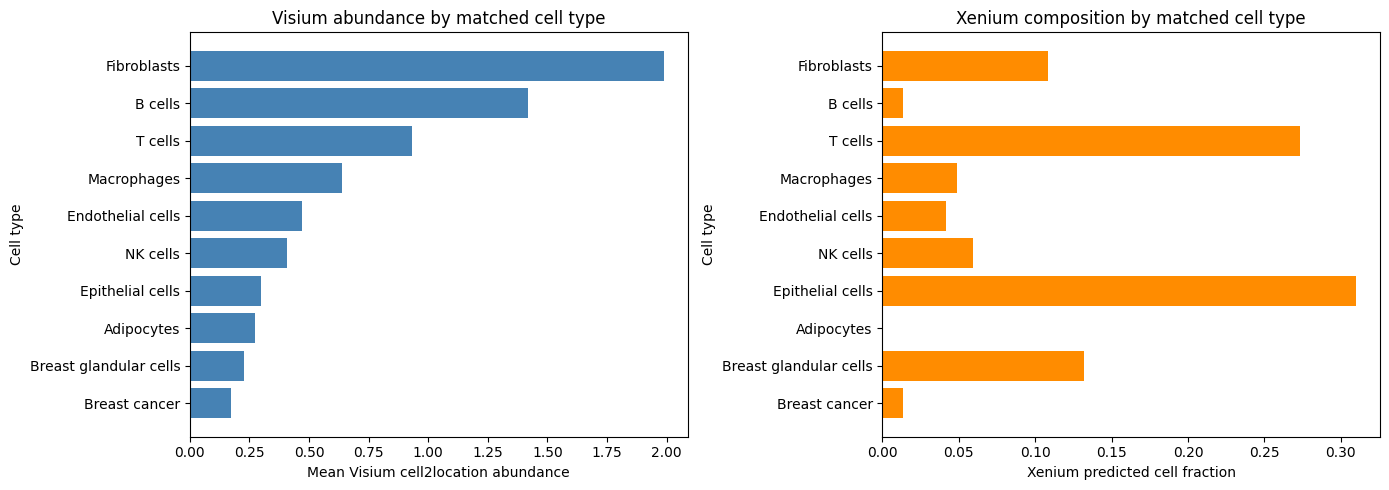

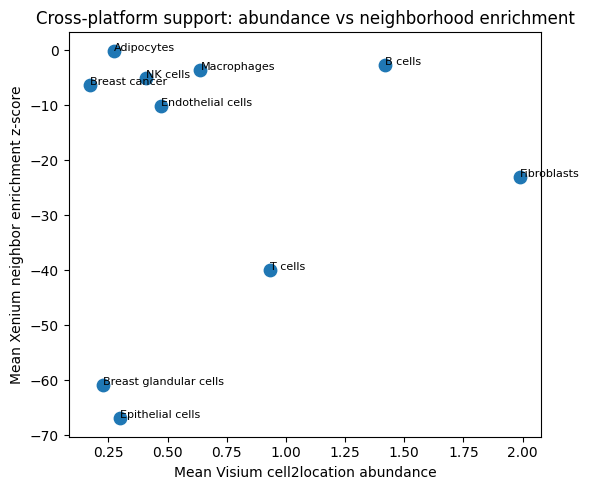

In [9]:
plot_df = cmp.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(plot_df["raw_label"], plot_df["visium_mean_abundance"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean Visium cell2location abundance")
axes[0].set_ylabel("Cell type")
axes[0].set_title("Visium abundance by matched cell type")

axes[1].barh(plot_df["raw_label"], plot_df["xenium_cell_fraction"], color="darkorange")
axes[1].invert_yaxis()
axes[1].set_xlabel("Xenium predicted cell fraction")
axes[1].set_ylabel("Cell type")
axes[1].set_title("Xenium composition by matched cell type")

plt.tight_layout()
plt.show()

if plot_df["xenium_mean_neighbor_z"].notna().sum() >= 3:
    plt.figure(figsize=(6, 5))
    plt.scatter(plot_df["visium_mean_abundance"], plot_df["xenium_mean_neighbor_z"], s=80)
    for _, row in plot_df.iterrows():
        plt.text(row["visium_mean_abundance"], row["xenium_mean_neighbor_z"], row["raw_label"], fontsize=8)
    plt.xlabel("Mean Visium cell2location abundance")
    plt.ylabel("Mean Xenium neighbor enrichment z-score")
    plt.title("Cross-platform support: abundance vs neighborhood enrichment")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough Xenium neighborhood z-scores available for scatter comparison.")

In [11]:
metrics_df = cmp[["raw_label", "visium_mean_abundance", "xenium_cell_fraction"]].copy()
metrics_df = metrics_df.dropna(subset=["visium_mean_abundance", "xenium_cell_fraction"]).reset_index(drop=True)

if metrics_df.shape[0] >= 3:
    pearson_r = metrics_df["visium_mean_abundance"].corr(metrics_df["xenium_cell_fraction"], method="pearson")
    spearman_r = metrics_df["visium_mean_abundance"].corr(metrics_df["xenium_cell_fraction"], method="spearman")
    print(f"Pearson r (Visium abundance vs Xenium fraction): {pearson_r:.3f}")
    print(f"Spearman rho (rank concordance): {spearman_r:.3f}")

    v = metrics_df["visium_mean_abundance"]
    x = metrics_df["xenium_cell_fraction"]
    visium_z = (v - v.mean()) / v.std(ddof=0)
    xenium_z = (x - x.mean()) / x.std(ddof=0)
    metrics_df["discordance_z"] = (visium_z - xenium_z).abs()

    discordant = metrics_df.sort_values("discordance_z", ascending=False).reset_index(drop=True)
    display(discordant[["raw_label", "visium_mean_abundance", "xenium_cell_fraction", "discordance_z"]])
else:
    print("Not enough matched cell types for robust correlation metrics (need >= 3).")

Pearson r (Visium abundance vs Xenium fraction): 0.011
Spearman rho (rank concordance): 0.103


,raw_label,visium_mean_abundance,xenium_cell_fraction,discordance_z
0,Epithelial cells,0.299260,0.310126,2.699913
1,Fibroblasts,1.988481,0.108559,2.220318
2,B cells,1.417875,0.013414,2.129963
3,T cells,0.933690,0.272965,1.223096
4,Breast glandular cells,0.226328,0.132137,1.114810
5,Macrophages,0.639302,0.048503,0.418857
6,Adipocytes,0.272133,0.000148,0.236816
7,Endothelial cells,0.471566,0.041701,0.188496
8,NK cells,0.408074,0.059027,0.090312
9,Breast cancer,0.172724,0.013421,0.066318


## Pairwise co-occurrence concordance (Visium vs Xenium neighborhoods)
For each matched cell-type pair (A, B), compare Visium spot-level co-occurrence (Spearman correlation across spots) with Xenium neighborhood enrichment (A-B z-score).

Pairwise concordance Pearson r: 0.468
Pairwise concordance Spearman rho: 0.543
Evaluated pairs: 45
-0.20386392387082794 0.8198224471054986 -242.83218669739 85.57904932844657


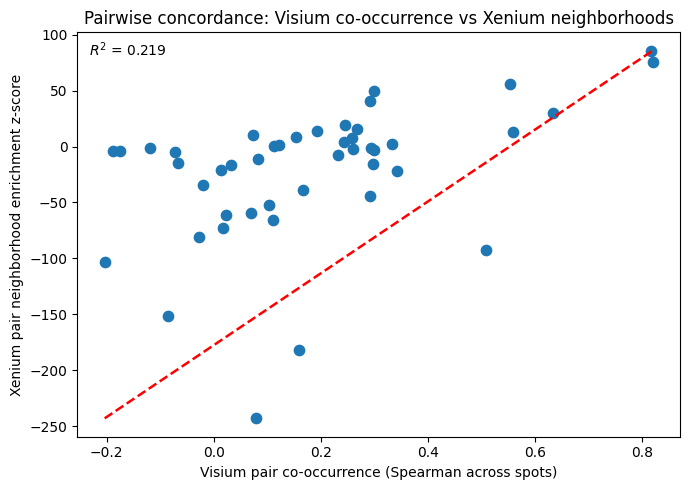

,pair,visium_pair_coocc_spearman,xenium_pair_neighbor_z,support_score
0,B cells | T cells,0.819822,75.676312,0.988889
1,Breast cancer | Epithelial cells,0.817586,85.579049,0.988889
2,Macrophages | T cells,0.552690,55.596084,0.933333
3,Endothelial cells | NK cells,0.634361,29.688092,0.922222
4,B cells | Macrophages,0.559413,13.173520,0.866667
5,Fibroblasts | Macrophages,0.299259,49.331419,0.866667
6,Endothelial cells | T cells,0.291245,40.453009,0.811111
7,B cells | Fibroblasts,0.267396,15.568504,0.766667
8,Adipocytes | Endothelial cells,0.333080,2.168684,0.766667
9,Breast glandular cells | NK cells,0.244481,18.905095,0.744444


In [21]:
from itertools import combinations

# Canon -> Visium column mapping
vis_col_map = {}
for c in c2l_cols:
    c_raw = strip_visium_label(c)
    c_can = canon(c_raw)
    vis_col_map[c_can] = c

# Canon -> Xenium label mapping
xen_label_map = dict(zip(xen_freq_df["canon"], xen_freq_df["raw_label"]))

matched_canons = sorted(set(cmp["canon"]).intersection(vis_col_map).intersection(xen_label_map))
pairs = []

if "z" not in globals() or z is None:
    print("Xenium neighborhood z-score matrix not available in memory.")
else:
    for a, b in combinations(matched_canons, 2):
        vis_a = adata_vis.obs[vis_col_map[a]]
        vis_b = adata_vis.obs[vis_col_map[b]]
        vis_coocc_spearman = vis_a.corr(vis_b, method="spearman")

        xa = xen_label_map[a]
        xb = xen_label_map[b]
        xen_z_ab = np.nan
        if xa in z.index and xb in z.columns:
            xen_z_ab = z.loc[xa, xb]
        elif xb in z.index and xa in z.columns:
            xen_z_ab = z.loc[xb, xa]

        pairs.append({
            "cell_type_a": xa,
            "cell_type_b": xb,
            "pair": f"{xa} | {xb}",
            "visium_pair_coocc_spearman": vis_coocc_spearman,
            "xenium_pair_neighbor_z": xen_z_ab,
        })

pair_df = pd.DataFrame(pairs)
pair_df = pair_df.dropna(subset=["visium_pair_coocc_spearman", "xenium_pair_neighbor_z"]).reset_index(drop=True)

if pair_df.shape[0] >= 3:
    pair_pearson = pair_df["visium_pair_coocc_spearman"].corr(pair_df["xenium_pair_neighbor_z"], method="pearson")
    pair_spearman = pair_df["visium_pair_coocc_spearman"].corr(pair_df["xenium_pair_neighbor_z"], method="spearman")
    print(f"Pairwise concordance Pearson r: {pair_pearson:.3f}")
    print(f"Pairwise concordance Spearman rho: {pair_spearman:.3f}")
    print(f"Evaluated pairs: {pair_df.shape[0]}")

    plt.figure(figsize=(7, 5))
    plt.scatter(pair_df["visium_pair_coocc_spearman"], pair_df["xenium_pair_neighbor_z"], s=55)
    plt.xlabel("Visium pair co-occurrence (Spearman across spots)")
    plt.ylabel("Xenium pair neighborhood enrichment z-score")
    plt.title("Pairwise concordance: Visium co-occurrence vs Xenium neighborhoods")
    plt.tight_layout()

    # build common range for reference line
    x = pair_df["visium_pair_coocc_spearman"]
    y = pair_df["xenium_pair_neighbor_z"]
    print(x.min(), x.max(), y.min(), y.max())
    # y = x reference (red dashed)
    plt.plot([x.min(), x.max()], [y.min(), y.max()], "r--", linewidth=1.8, label="y = x")


    # R^2 annotation
    r2 = pair_pearson ** 2
    plt.text(
    0.02, 0.98, f"$R^2$ = {r2:.3f}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    plt.show()

    pair_df["support_score"] = (
        pair_df["visium_pair_coocc_spearman"].rank(pct=True)
        + pair_df["xenium_pair_neighbor_z"].rank(pct=True)
    ) / 2

    top_supported_pairs = pair_df.sort_values("support_score", ascending=False).head(10).reset_index(drop=True)
    display(top_supported_pairs[["pair", "visium_pair_coocc_spearman", "xenium_pair_neighbor_z", "support_score"]])
else:
    print("Not enough valid A-B pairs for pairwise concordance analysis (need >= 3).")

## Save comparison table

In [22]:
cmp_out = OUT_DIR / "cross_platform_visium_xenium_comparison.csv"
cmp.to_csv(cmp_out, index=False)
print(f"Saved: {cmp_out}")

Saved: ../data/xenium/cross_platform_visium_xenium_comparison.csv
